# Design Challenge 2 - Task 5

This notebook completes **Task 5: Extending the System by Adding a New Gesture Class** for group `15`.

For group `15`, the assigned new class is letter `P` because `15 % 26 = 15`, which maps to `P`.

The notebook trains and compares:

- a **10-class baseline model** for digits `0-9`
- an **11-class extended model** for digits `0-9` plus letter `P`

It then analyses:

- the impact on digit recognition accuracy
- how well the new letter is recognised
- confusion between classes
- a consistency metric for repeated recordings of letter `P`


## What This Notebook Does

1. Downloads the original Magic Wand digit dataset.
2. Uploads the personal letter dataset `wanddata_P.json`.
3. Rebuilds the baseline `10-class` split using the original ratio.
4. Creates an `11-class` split by adding the new letter `P`.
5. Trains the baseline CNN on both setups.
6. Exports Keras, quantized TFLite, and `.cc` model files.
7. Reports:
   - baseline digit accuracy
   - extended digit accuracy
   - full 11-class accuracy
   - new-letter accuracy
   - new-letter consistency
   - confusion matrix and confusion pairs involving `P`


In [1]:
%tensorflow_version 2.x

import os
import math
import glob
import json
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import files


Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
GROUP_ID = 15
LETTER_OFFSET = GROUP_ID % 26
NEW_LETTER = chr(ord('A') + LETTER_OFFSET)
LETTER_LABEL = NEW_LETTER.lower()
PERSONAL_FILENAME = f'wanddata_{NEW_LETTER}.json'
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

WORK_DIR = Path('/content/dc2_task5')
ORIG_DIR = WORK_DIR / 'original_dataset'
PERSONAL_DATA_DIR = WORK_DIR / 'personal_data'
BASELINE_DATA_DIR = WORK_DIR / 'baseline_split'
EXTENDED_DATA_DIR = WORK_DIR / 'extended_split'
MODELS_DIR = WORK_DIR / 'models'
RESULTS_DIR = WORK_DIR / 'results'
CHKPT_DIR = WORK_DIR / 'checkpoints'

for path in [WORK_DIR, ORIG_DIR, PERSONAL_DATA_DIR, BASELINE_DATA_DIR, EXTENDED_DATA_DIR, MODELS_DIR, RESULTS_DIR, CHKPT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - TEST_PERCENTAGE - VALIDATION_PERCENTAGE

IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
BATCH_SIZE = 32
BASELINE_EPOCHS = 30
EXTENDED_EPOCHS = 30
TRAIN_AUGMENT_COUNT = 10
EVAL_AUGMENT_COUNT = 10

print('GROUP_ID =', GROUP_ID)
print('Assigned new letter =', NEW_LETTER)
print('Expected upload file =', PERSONAL_FILENAME)
print('Split ratio preserved:', TRAIN_PERCENTAGE, VALIDATION_PERCENTAGE, TEST_PERCENTAGE)


GROUP_ID = 15
Assigned new letter = P
Expected upload file = wanddata_P.json
Split ratio preserved: 60 30 10


## Download the Original Baseline Dataset

This uses the same baseline digit dataset as `Baseline.ipynb`, `4.2.ipynb`, and `4.3.ipynb`.


In [3]:
%cd /content
!rm -rf magic_wand_digit_data-* magic_wand_digit_data.zip
!curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
!unzip -qq -o magic_wand_digit_data.zip
!rm -rf {ORIG_DIR}
!mkdir -p {ORIG_DIR}
!mv magic_wand_digit_data-*/* {ORIG_DIR}/

print('Original dataset extracted to:', ORIG_DIR)
print('JSON files:', len(list(ORIG_DIR.glob('*.json'))))


/content
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  238k    0  238k    0     0   359k      0 --:--:-- --:--:-- --:--:-- 1339k
Original dataset extracted to: /content/dc2_task5/original_dataset
JSON files: 10


## Upload the Personal Letter Dataset

Upload:

- `design-challenge-2/dataset/wanddata_P.json`

The upload cell is tolerant of Colab renaming the file to names such as `wanddata_P (1).json`.


In [4]:
uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

matched_name = None
expected_stem = PERSONAL_FILENAME.replace('.json', '')
for uploaded_name in uploaded.keys():
    if uploaded_name == PERSONAL_FILENAME or uploaded_name.startswith(expected_stem):
        matched_name = uploaded_name
        break

if matched_name is None:
    raise FileNotFoundError(f'Missing required personal dataset file: {PERSONAL_FILENAME}')

(PERSONAL_DATA_DIR / PERSONAL_FILENAME).write_bytes(uploaded[matched_name])
print('Saved uploaded dataset to:', PERSONAL_DATA_DIR / PERSONAL_FILENAME)


Saving wanddata_P.json to wanddata_P.json
Uploaded files: ['wanddata_P.json']
Saved uploaded dataset to: /content/dc2_task5/personal_data/wanddata_P.json


In [5]:
FIXED_POINT = 256
X_RANGE = 0.6
Y_RANGE = 0.6


def mul_fp(a, b):
    return (a * b) / FIXED_POINT


def div_fp(a, b):
    if b == 0:
        b = 1
    return (a * FIXED_POINT) / b


def float_to_fp(a):
    return math.floor(a * FIXED_POINT)


def norm_to_coord_fp(a, range_fp, half_size_fp):
    a_fp = float_to_fp(a)
    norm_fp = div_fp(a_fp, range_fp)
    return mul_fp(norm_fp, half_size_fp) + half_size_fp


def round_fp_to_int(a):
    return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)


def gate(a, min_value, max_value):
    if a < min_value:
        return min_value
    if a > max_value:
        return max_value
    return a


def rasterize_stroke(stroke_points, x_range, y_range, width, height):
    num_channels = 3
    buffer_byte_count = height * width * num_channels
    buffer = bytearray(buffer_byte_count)

    width_fp = width * FIXED_POINT
    height_fp = height * FIXED_POINT
    half_width_fp = width_fp / 2
    half_height_fp = height_fp / 2
    x_range_fp = float_to_fp(x_range)
    y_range_fp = float_to_fp(y_range)
    t_inc_fp = FIXED_POINT / len(stroke_points)
    one_half_fp = FIXED_POINT / 2

    for point_index in range(len(stroke_points) - 1):
        start_point = stroke_points[point_index]
        end_point = stroke_points[point_index + 1]
        start_x_fp = norm_to_coord_fp(start_point['x'], x_range_fp, half_width_fp)
        start_y_fp = norm_to_coord_fp(-start_point['y'], y_range_fp, half_height_fp)
        end_x_fp = norm_to_coord_fp(end_point['x'], x_range_fp, half_width_fp)
        end_y_fp = norm_to_coord_fp(-end_point['y'], y_range_fp, half_height_fp)
        delta_x_fp = end_x_fp - start_x_fp
        delta_y_fp = end_y_fp - start_y_fp

        t_fp = point_index * t_inc_fp
        if t_fp < one_half_fp:
            local_t_fp = div_fp(t_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = round_fp_to_int(one_minus_t_fp * 255)
            green = round_fp_to_int(local_t_fp * 255)
            blue = 0
        else:
            local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = 0
            green = round_fp_to_int(one_minus_t_fp * 255)
            blue = round_fp_to_int(local_t_fp * 255)

        red = gate(red, 0, 255)
        green = gate(green, 0, 255)
        blue = gate(blue, 0, 255)

        if abs(delta_x_fp) > abs(delta_y_fp):
            line_length = abs(round_fp_to_int(delta_x_fp))
            if delta_x_fp > 0:
                x_inc_fp = FIXED_POINT
                y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
            else:
                x_inc_fp = -FIXED_POINT
                y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
        else:
            line_length = abs(round_fp_to_int(delta_y_fp))
            if delta_y_fp > 0:
                y_inc_fp = FIXED_POINT
                x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
            else:
                y_inc_fp = -FIXED_POINT
                x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)

        for i in range(line_length + 1):
            x_fp = start_x_fp + (i * x_inc_fp)
            y_fp = start_y_fp + (i * y_inc_fp)
            x = round_fp_to_int(x_fp)
            y = round_fp_to_int(y_fp)
            if (x < 0) or (x >= width) or (y < 0) or (y >= height):
                continue
            buffer_index = (y * width * num_channels) + (x * num_channels)
            buffer[buffer_index + 0] = red
            buffer[buffer_index + 1] = green
            buffer[buffer_index + 2] = blue

    return np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)


def ensure_empty_dir(dirname):
    dirpath = Path(dirname)
    if dirpath.exists() and dirpath.is_dir():
        shutil.rmtree(dirpath)
    dirpath.mkdir(parents=True, exist_ok=True)


def augment_points(points, move_range, scale_range, rotate_range):
    move_x = np.random.uniform(low=-move_range, high=move_range)
    move_y = np.random.uniform(low=-move_range, high=move_range)
    scale = np.random.uniform(low=1.0 - scale_range, high=1.0 + scale_range)
    rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

    x_axis_x = math.cos(rotate) * scale
    x_axis_y = math.sin(rotate) * scale
    y_axis_x = -math.sin(rotate) * scale
    y_axis_y = math.cos(rotate) * scale

    new_points = []
    for point in points:
        old_x = point['x']
        old_y = point['y']
        new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
        new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
        new_points.append({'x': new_x, 'y': new_y})
    return new_points


def save_strokes_as_images(strokes_subset, root_folder, width, height, augment_count):
    ensure_empty_dir(root_folder)
    labels = sorted({stroke['label'].lower() for stroke in strokes_subset})
    for label in labels:
        Path(root_folder, label).mkdir(parents=True, exist_ok=True)

    for idx, stroke in enumerate(strokes_subset):
        label = stroke['label'].lower()
        raster = rasterize_stroke(stroke['strokePoints'], X_RANGE, Y_RANGE, width, height)
        PIL.Image.fromarray(raster).save(Path(root_folder, label, f'{idx:05d}.png'))

        for aug_idx in range(augment_count):
            raster_aug = rasterize_stroke(
                augment_points(stroke['strokePoints'], 0.08, 0.08, 0.18),
                X_RANGE,
                Y_RANGE,
                width,
                height,
            )
            PIL.Image.fromarray(raster_aug).save(Path(root_folder, label, f'{idx:05d}_aug{aug_idx}.png'))

    return set(labels)


def load_strokes_from_json_dir(json_dir):
    strokes = []
    for filename in sorted(glob.glob(str(Path(json_dir) / '*.json'))):
        with open(filename, 'r') as file:
            file_data = json.load(file)
        for stroke in file_data['strokes']:
            stroke['filename'] = filename
            strokes.append(stroke)
    return strokes


def split_strokes(strokes, seed):
    local = list(strokes)
    rng = random.Random(seed)
    rng.shuffle(local)
    test_count = math.floor((len(local) * TEST_PERCENTAGE) / 100)
    validation_count = math.floor((len(local) * VALIDATION_PERCENTAGE) / 100)
    test_strokes = local[:test_count]
    validation_strokes = local[test_count:test_count + validation_count]
    train_strokes = local[test_count + validation_count:]
    return train_strokes, validation_strokes, test_strokes


def split_personal_by_label(personal_strokes, seed):
    grouped = defaultdict(list)
    for stroke in personal_strokes:
        grouped[stroke['label'].lower()].append(stroke)

    train, val, test = [], [], []
    for offset, label in enumerate(sorted(grouped)):
        label_train, label_val, label_test = split_strokes(grouped[label], seed + offset)
        train.extend(label_train)
        val.extend(label_val)
        test.extend(label_test)
    return train, val, test


In [6]:
original_strokes = load_strokes_from_json_dir(ORIG_DIR)
personal_strokes = load_strokes_from_json_dir(PERSONAL_DATA_DIR)

print('Original strokes:', len(original_strokes))
print('Personal letter strokes:', len(personal_strokes))
print('Personal label counts:')
print(pd.Series([stroke['label'] for stroke in personal_strokes]).value_counts())


Original strokes: 1000
Personal letter strokes: 30
Personal label counts:
P    30
Name: count, dtype: int64


## Build the 10-Class and 11-Class Splits

The original digit split keeps the provided ratio unchanged. The personal `P` samples are split separately using the same ratio, then merged into the extended `11-class` dataset.


In [7]:
baseline_train_strokes, baseline_val_strokes, baseline_test_strokes = split_strokes(original_strokes, SEED)
letter_train_strokes, letter_val_strokes, letter_test_strokes = split_personal_by_label(personal_strokes, SEED + 500)

extended_train_strokes = baseline_train_strokes + letter_train_strokes
extended_val_strokes = baseline_val_strokes + letter_val_strokes
extended_test_strokes = baseline_test_strokes + letter_test_strokes

print('Baseline split sizes:', len(baseline_train_strokes), len(baseline_val_strokes), len(baseline_test_strokes))
print('Letter split sizes:', len(letter_train_strokes), len(letter_val_strokes), len(letter_test_strokes))
print('Extended split sizes:', len(extended_train_strokes), len(extended_val_strokes), len(extended_test_strokes))


Baseline split sizes: 600 300 100
Letter split sizes: 18 9 3
Extended split sizes: 618 309 103


In [8]:
BASELINE_TRAIN_DIR = BASELINE_DATA_DIR / 'train'
BASELINE_VAL_DIR = BASELINE_DATA_DIR / 'val'
BASELINE_TEST_DIR = BASELINE_DATA_DIR / 'test'
EXTENDED_TRAIN_DIR = EXTENDED_DATA_DIR / 'train'
EXTENDED_VAL_DIR = EXTENDED_DATA_DIR / 'val'
EXTENDED_TEST_DIR = EXTENDED_DATA_DIR / 'test'

save_strokes_as_images(baseline_train_strokes, BASELINE_TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, TRAIN_AUGMENT_COUNT)
save_strokes_as_images(baseline_val_strokes, BASELINE_VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, EVAL_AUGMENT_COUNT)
save_strokes_as_images(baseline_test_strokes, BASELINE_TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, EVAL_AUGMENT_COUNT)

save_strokes_as_images(extended_train_strokes, EXTENDED_TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, TRAIN_AUGMENT_COUNT)
save_strokes_as_images(extended_val_strokes, EXTENDED_VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, EVAL_AUGMENT_COUNT)
save_strokes_as_images(extended_test_strokes, EXTENDED_TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, EVAL_AUGMENT_COUNT)

print('Image datasets prepared.')


Image datasets prepared.


In [9]:
def build_dataset_splits(train_dir, val_dir, test_dir):
    train_ds = image_dataset_from_directory(
        directory=train_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=True,
        seed=SEED,
    ).prefetch(buffer_size=32)

    validation_ds = image_dataset_from_directory(
        directory=val_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=False,
    ).prefetch(buffer_size=32)

    test_ds = image_dataset_from_directory(
        directory=test_dir,
        labels='inferred',
        label_mode='categorical',
        batch_size=BATCH_SIZE,
        image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
        shuffle=False,
    ).prefetch(buffer_size=32)

    labels = sorted(path.name for path in Path(train_dir).iterdir() if path.is_dir())
    label_to_int = {label: idx for idx, label in enumerate(labels)}
    int_to_label = {idx: label for label, idx in label_to_int.items()}
    return train_ds, validation_ds, test_ds, labels, label_to_int, int_to_label

baseline_train_ds, baseline_val_ds, baseline_test_ds, baseline_labels, baseline_label_to_int, baseline_int_to_label = build_dataset_splits(
    BASELINE_TRAIN_DIR, BASELINE_VAL_DIR, BASELINE_TEST_DIR
)
extended_train_ds, extended_val_ds, extended_test_ds, extended_labels, extended_label_to_int, extended_int_to_label = build_dataset_splits(
    EXTENDED_TRAIN_DIR, EXTENDED_VAL_DIR, EXTENDED_TEST_DIR
)

print('Baseline labels:', baseline_labels)
print('Extended labels:', extended_labels)


Found 6600 files belonging to 10 classes.
Found 3300 files belonging to 10 classes.
Found 1100 files belonging to 10 classes.
Found 6798 files belonging to 11 classes.
Found 3399 files belonging to 11 classes.
Found 1133 files belonging to 11 classes.
Baseline labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Extended labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'p']


## Baseline CNN Architecture

This uses the same baseline CNN structure as the earlier coursework tasks, with only the output dimension changed between the `10-class` and `11-class` runs.


In [10]:
def make_baseline_model(input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(16, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name=f'baseline_cnn_{num_classes}class')

preview_model = make_baseline_model(num_classes=len(extended_labels))
preview_model.summary()


Model: "baseline_cnn_11class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,019 (58.67 KB)

 Trainable params: 14,859 (58.04 KB)

 Non-trainable params: 160 (640.00 B)

In [11]:
def representative_dataset_from_dir(test_dir):
    for filename in glob.glob(str(Path(test_dir) / '*/*.png')):
        img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        yield [img_array]


def predict_tflite_batch(tflite_model, images_batch):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    outputs = []
    for img_array in images_batch:
        img_array = np.expand_dims(img_array, axis=0)
        input_scale, input_zero_point = input_details['quantization']
        if (input_scale, input_zero_point) != (0.0, 0):
            img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
            img_array = img_array.astype(input_details['dtype'])

        interpreter.set_tensor(input_details['index'], img_array)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details['index'])[0]

        output_scale, output_zero_point = output_details['quantization']
        if (output_scale, output_zero_point) != (0.0, 0):
            pred = pred.astype(np.float32)
            pred = np.multiply((pred - output_zero_point), output_scale)
        outputs.append(pred)

    return np.array(outputs)


def export_c_array(tflite_path, cc_path, variable_name='g_magic_wand_model_data'):
    !xxd -i {tflite_path} > {cc_path}
    replace_text = str(tflite_path).replace('/', '_').replace('.', '_')
    cc_text = Path(cc_path).read_text()
    cc_text = cc_text.replace(replace_text, variable_name)
    Path(cc_path).write_text(cc_text)


def train_and_export(model_name, train_ds, val_ds, representative_test_dir, num_classes, epochs):
    keras.backend.clear_session()
    model = make_baseline_model(num_classes=num_classes)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    checkpoint_path = CHKPT_DIR / f'{model_name}.keras'
    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max'),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    keras_path = MODELS_DIR / f'{model_name}.keras'
    float_tfl_path = MODELS_DIR / f'{model_name}_float.tflite'
    quant_tfl_path = MODELS_DIR / f'{model_name}_quant.tflite'
    cc_path = MODELS_DIR / f'{model_name}.cc'

    model.save(keras_path)

    float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    float_tflite_model = float_converter.convert()
    with open(float_tfl_path, 'wb') as f:
        f.write(float_tflite_model)

    quant_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    quant_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    quant_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    quant_converter.inference_input_type = tf.int8
    quant_converter.inference_output_type = tf.int8
    quant_converter.representative_dataset = lambda: representative_dataset_from_dir(representative_test_dir)
    quant_tflite_model = quant_converter.convert()
    with open(quant_tfl_path, 'wb') as f:
        f.write(quant_tflite_model)

    export_c_array(quant_tfl_path, cc_path)

    return {
        'model_name': model_name,
        'model': model,
        'history': history,
        'keras_path': keras_path,
        'quant_tflite_model': quant_tflite_model,
        'quant_tfl_path': quant_tfl_path,
        'quant_tflite_size_bytes': os.path.getsize(quant_tfl_path),
        'cc_path': cc_path,
    }


## Train the Baseline and Extended Models


In [12]:
baseline_run = train_and_export(
    model_name='task5_baseline_10class',
    train_ds=baseline_train_ds,
    val_ds=baseline_val_ds,
    representative_test_dir=BASELINE_TEST_DIR,
    num_classes=len(baseline_labels),
    epochs=BASELINE_EPOCHS,
)

extended_run = train_and_export(
    model_name='task5_extended_11class',
    train_ds=extended_train_ds,
    val_ds=extended_val_ds,
    representative_test_dir=EXTENDED_TEST_DIR,
    num_classes=len(extended_labels),
    epochs=EXTENDED_EPOCHS,
)

print('Training complete.')
print('Extended .cc export:', extended_run['cc_path'])


Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.1247 - loss: 0.4472 - val_accuracy: 0.1100 - val_loss: 0.3294
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1741 - loss: 0.3341 - val_accuracy: 0.1224 - val_loss: 0.3203
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2247 - loss: 0.3171 - val_accuracy: 0.3718 - val_loss: 0.2923
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.2620 - loss: 0.3055 - val_accuracy: 0.5458 - val_loss: 0.2710
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.3061 - loss: 0.2948 - val_accuracy: 0.6491 - val_loss: 0.2548
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3359 - loss: 0.2830 - val_accuracy: 0.7106 - val_loss: 0.2395
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3655 - loss: 0.2736 - val_accuracy: 0.7821 - val_loss: 0.2269
Epoch 8/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4029 - loss: 0.2629 - val_acc

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.1117 - loss: 0.4658 - val_accuracy: 0.1068 - val_loss: 0.3141
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1528 - loss: 0.3155 - val_accuracy: 0.1174 - val_loss: 0.2959
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2042 - loss: 0.2978 - val_accuracy: 0.4313 - val_loss: 0.2669
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.2429 - loss: 0.2881 - val_accuracy: 0.5016 - val_loss: 0.2524
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2817 - loss: 0.2751 - val_accuracy: 0.5908 - val_loss: 0.2369
Epoch 6/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3210 - loss: 0.2644 - val_accuracy: 0.6381 - val_loss: 0.2295
Epoch 7/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3542 - loss: 0.2539 - val_accuracy: 0.7264 - val_loss: 0.2154
Epoch 8/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.3786 - loss: 0.2474 - val_accu

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Training complete.
Extended .cc export: /content/dc2_task5/models/task5_extended_11class.cc


## Evaluation and Analysis


In [13]:
def predict_single_stroke_keras(model, labels, stroke):
    raster = rasterize_stroke(stroke['strokePoints'], X_RANGE, Y_RANGE, IMAGE_WIDTH, IMAGE_HEIGHT)
    img_array = np.expand_dims(raster.astype(np.float32), axis=0)
    predictions = model.predict(img_array, verbose=0).flatten()
    pred_idx = int(np.argmax(predictions))
    pred_label = labels[pred_idx]
    return pred_label, float(predictions[pred_idx])


def predict_single_stroke_tflite(tflite_model, labels, stroke):
    raster = rasterize_stroke(stroke['strokePoints'], X_RANGE, Y_RANGE, IMAGE_WIDTH, IMAGE_HEIGHT)
    preds = predict_tflite_batch(tflite_model, np.expand_dims(raster.astype(np.float32), axis=0))[0]
    pred_idx = int(np.argmax(preds))
    pred_label = labels[pred_idx]
    return pred_label, float(preds[pred_idx])


def evaluate_subset(model, labels, strokes_subset, model_kind='keras'):
    rows = []
    for stroke in strokes_subset:
        if model_kind == 'keras':
            pred_label, confidence = predict_single_stroke_keras(model, labels, stroke)
        else:
            pred_label, confidence = predict_single_stroke_tflite(model, labels, stroke)
        rows.append({
            'true_label': stroke['label'].lower(),
            'pred_label': pred_label,
            'confidence': confidence,
            'index': stroke.get('index'),
        })

    df = pd.DataFrame(rows)
    accuracy = float((df['true_label'] == df['pred_label']).mean()) if len(df) else 0.0
    return df, accuracy


def consistency_from_prediction_df(df):
    pred_counts = df['pred_label'].value_counts()
    modal_label = pred_counts.index[0]
    modal_count = int(pred_counts.iloc[0])
    total = int(len(df))
    consistency = modal_count / total if total else 0.0
    accuracy = float((df['true_label'] == df['pred_label']).mean()) if total else 0.0
    return pd.DataFrame([{
        'gesture': df['true_label'].iloc[0] if total else LETTER_LABEL,
        'samples': total,
        'modal_prediction': modal_label,
        'modal_count': modal_count,
        'consistency_pct': round(consistency * 100, 2),
        'accuracy_pct': round(accuracy * 100, 2),
    }]), round(consistency * 100, 2)


In [14]:
baseline_digits_keras_df, baseline_digits_keras_acc = evaluate_subset(
    baseline_run['model'], baseline_labels, baseline_test_strokes, model_kind='keras'
)
baseline_digits_quant_df, baseline_digits_quant_acc = evaluate_subset(
    baseline_run['quant_tflite_model'], baseline_labels, baseline_test_strokes, model_kind='tflite'
)

extended_digits_keras_df, extended_digits_keras_acc = evaluate_subset(
    extended_run['model'], extended_labels, baseline_test_strokes, model_kind='keras'
)
extended_digits_quant_df, extended_digits_quant_acc = evaluate_subset(
    extended_run['quant_tflite_model'], extended_labels, baseline_test_strokes, model_kind='tflite'
)

extended_full_keras_df, extended_full_keras_acc = evaluate_subset(
    extended_run['model'], extended_labels, extended_test_strokes, model_kind='keras'
)
extended_full_quant_df, extended_full_quant_acc = evaluate_subset(
    extended_run['quant_tflite_model'], extended_labels, extended_test_strokes, model_kind='tflite'
)

letter_test_keras_df, letter_test_keras_acc = evaluate_subset(
    extended_run['model'], extended_labels, letter_test_strokes, model_kind='keras'
)
letter_test_quant_df, letter_test_quant_acc = evaluate_subset(
    extended_run['quant_tflite_model'], extended_labels, letter_test_strokes, model_kind='tflite'
)

letter_all_keras_df, letter_all_keras_acc = evaluate_subset(
    extended_run['model'], extended_labels, personal_strokes, model_kind='keras'
)
letter_all_quant_df, letter_all_quant_acc = evaluate_subset(
    extended_run['quant_tflite_model'], extended_labels, personal_strokes, model_kind='tflite'
)

letter_consistency_df, letter_consistency_pct = consistency_from_prediction_df(letter_all_keras_df)

summary_df = pd.DataFrame([{
    'group_id': GROUP_ID,
    'new_letter': NEW_LETTER,
    'baseline_pc_digit_accuracy_pct': round(baseline_digits_keras_acc * 100, 2),
    'baseline_quant_digit_accuracy_pct': round(baseline_digits_quant_acc * 100, 2),
    'extended_pc_digit_accuracy_pct': round(extended_digits_keras_acc * 100, 2),
    'extended_quant_digit_accuracy_pct': round(extended_digits_quant_acc * 100, 2),
    'extended_pc_full_11class_accuracy_pct': round(extended_full_keras_acc * 100, 2),
    'extended_quant_full_11class_accuracy_pct': round(extended_full_quant_acc * 100, 2),
    'extended_pc_letter_test_accuracy_pct': round(letter_test_keras_acc * 100, 2),
    'extended_quant_letter_test_accuracy_pct': round(letter_test_quant_acc * 100, 2),
    'extended_pc_letter_repetition_accuracy_pct': round(letter_all_keras_acc * 100, 2),
    'extended_quant_letter_repetition_accuracy_pct': round(letter_all_quant_acc * 100, 2),
    'extended_letter_consistency_pct': round(letter_consistency_pct, 2),
    'extended_quant_tflite_size_bytes': extended_run['quant_tflite_size_bytes'],
}])

summary_df


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,group_id,new_letter,baseline_pc_digit_accuracy_pct,baseline_quant_digit_accuracy_pct,extended_pc_digit_accuracy_pct,extended_quant_digit_accuracy_pct,extended_pc_full_11class_accuracy_pct,extended_quant_full_11class_accuracy_pct,extended_pc_letter_test_accuracy_pct,extended_quant_letter_test_accuracy_pct,extended_pc_letter_repetition_accuracy_pct,extended_quant_letter_repetition_accuracy_pct,extended_letter_consistency_pct,extended_quant_tflite_size_bytes
0,15,P,96.0,96.0,94.0,94.0,94.17,94.17,100.0,100.0,90.0,90.0,90.0,21552


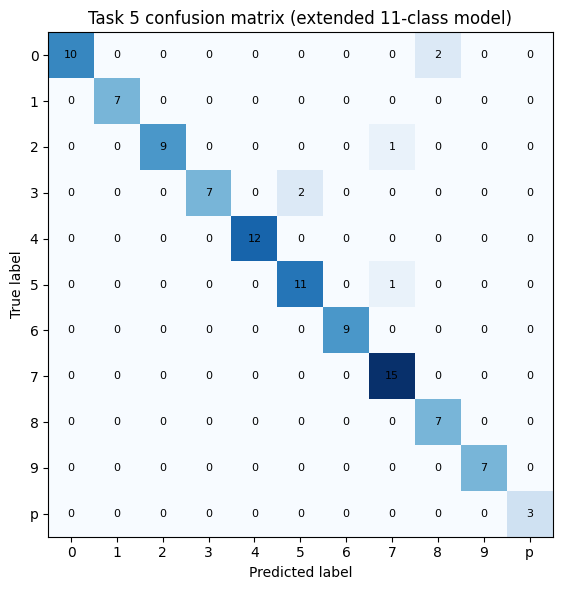

Confusion pairs involving p


,true_label,pred_label,count


In [15]:
confusion_df = pd.crosstab(
    extended_full_keras_df['true_label'],
    extended_full_keras_df['pred_label'],
    rownames=['true_label'],
    colnames=['pred_label'],
    dropna=False,
).reindex(index=extended_labels, columns=extended_labels, fill_value=0)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_df.values, cmap='Blues')
plt.xticks(range(len(confusion_df.columns)), confusion_df.columns)
plt.yticks(range(len(confusion_df.index)), confusion_df.index)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Task 5 confusion matrix (extended 11-class model)')
for y in range(confusion_df.shape[0]):
    for x in range(confusion_df.shape[1]):
        plt.text(x, y, int(confusion_df.iloc[y, x]), ha='center', va='center', color='black', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'task_5_confusion_matrix.png', dpi=160)
plt.show()

p_confusions_df = extended_full_keras_df[
    ((extended_full_keras_df['true_label'] == LETTER_LABEL) & (extended_full_keras_df['pred_label'] != LETTER_LABEL)) |
    ((extended_full_keras_df['true_label'] != LETTER_LABEL) & (extended_full_keras_df['pred_label'] == LETTER_LABEL))
].copy()

p_confusion_pairs_df = (
    p_confusions_df.groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print('Confusion pairs involving', LETTER_LABEL)
p_confusion_pairs_df


In [16]:
summary_df.to_csv(RESULTS_DIR / 'task_5_summary.csv', index=False)
letter_consistency_df.to_csv(RESULTS_DIR / 'task_5_letter_consistency.csv', index=False)
confusion_df.to_csv(RESULTS_DIR / 'task_5_confusion_matrix.csv')
p_confusion_pairs_df.to_csv(RESULTS_DIR / 'task_5_p_confusions.csv', index=False)
letter_all_keras_df.to_csv(RESULTS_DIR / 'task_5_letter_predictions.csv', index=False)

print('Saved results to:', RESULTS_DIR)
for path in sorted(RESULTS_DIR.glob('*')):
    print('-', path.name)


Saved results to: /content/dc2_task5/results
- task_5_confusion_matrix.csv
- task_5_confusion_matrix.png
- task_5_letter_consistency.csv
- task_5_letter_predictions.csv
- task_5_p_confusions.csv
- task_5_summary.csv


## Report Checklist

After this notebook finishes, the report can directly use:

- `task_5_summary.csv` for the main accuracy table
- `task_5_letter_consistency.csv` for the new-letter consistency metric
- `task_5_confusion_matrix.csv` and `task_5_p_confusions.csv` for the confusion analysis
- `task_5_confusion_matrix.png` as the supporting visual

Key discussion points:

- whether adding `P` reduces digit accuracy, and by how much
- how well `P` is recognised on held-out and repeated recordings
- which digits are most commonly confused with `P`, if any
- whether the small added functionality is worth the cost in accuracy or model size


In [17]:
files.download(str(RESULTS_DIR / 'task_5_summary.csv'))
files.download(str(RESULTS_DIR / 'task_5_letter_consistency.csv'))
files.download(str(RESULTS_DIR / 'task_5_confusion_matrix.csv'))
files.download(str(RESULTS_DIR / 'task_5_p_confusions.csv'))
files.download(str(RESULTS_DIR / 'task_5_confusion_matrix.png'))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>